<a href="https://colab.research.google.com/github/saim9211/DeepLearning/blob/main/01_pytorch_workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

resources : https://www.learnpytorch.io/01_pytorch_workflow/

In [1]:
import torch
from torch import nn # it contain all building block of the pytorch
import matplotlib.pyplot as plt

In [5]:
# data (preparing  and the loading )

# and the data can in any form (vedios,images,excels,audio,dns,text)
# we use the linear regression formula

#create the *known parameters
weight=0.7
bais=0.3
# create teh data
start=0
end =1
gap=0.02
X=torch.arange(start,end,gap).unsqueeze(dim=1)
y=weight*X+bais
y
print(len(y),len(X))

50 50


In [7]:
# splitting the data in to training and the testing
# creat the split
train_split=int(0.8*len(X))
X_train,y_train=X[:train_split],y[:train_split]
X_test,y_test=X[train_split:],y[train_split:]
len(X_test),len(X_train),len(y_test),len(y_train)


(10, 40, 10, 40)

In [13]:
# visualizing the data
def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=None):
  """ plots the taining data ,test and compare
  """
  plt.figure(figsize=(10,7))
  # plot the training data in blue
  plt.scatter(train_data,train_labels,c="b",s=4,label="training data")
  # are there prediction
  if predictions is not None:
    plt.scatter(train_data,predictions,c="g",s=4,label="prediction")
  # show the legend
  plt.legend(prop={"size":14})

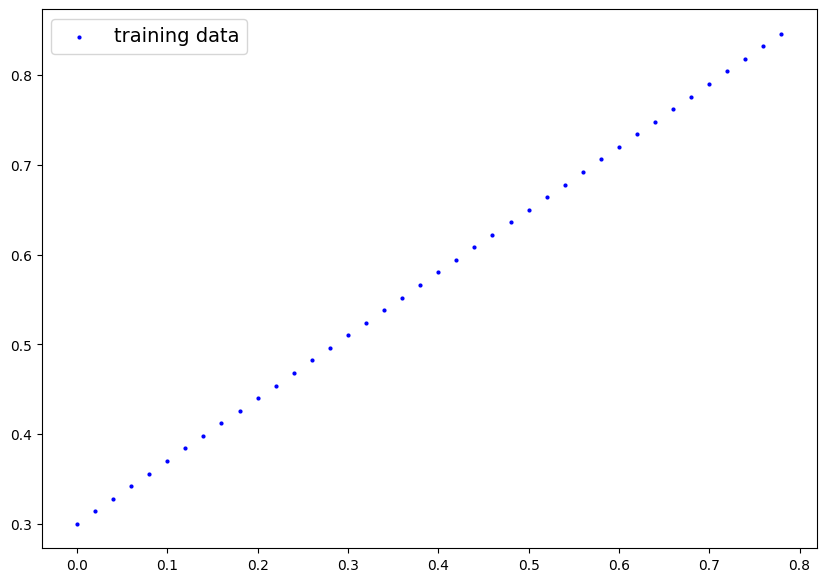

In [16]:
plot_predictions()

### pytorch model building essentials
1. nn.Module contains the larger building blocks (layers)
2. nn.Parameter contains the smaller parameters like weights and biases (put these together to make nn.Module(s))
3. forward() tells the larger blocks how to make calculations on inputs (tensors full of data) within nn.Module(s)
4. torch.optim contains optimization methods on how to improve the parameters within nn.Parameter to better represent input data

In [20]:
class LinearRegressionMode(nn.Module):
  def __init__(self):
    super().__init__()

    self.weights=nn.Parameter(torch.randn(1,
                                          requires_grad=True,
                                          dtype=torch.float))
    self.bais=nn.Parameter(torch.randn(1,
                                       requires_grad=True,
                                       dtype=torch.float))
# forward() define the computation in the model
  def forward(self, x:torch.Tensor)->torch.Tensor:
    return self.weights*x+self.bais